# BTC Price Forecasting
## Notebook 1 — Data Exploration

This notebook conducts a systematic investigation of the raw Coinbase BTC/USD dataset
prior to any transformation. Each section documents a concrete finding that directly
informs a preprocessing decision in Notebook 2.

**Source:** Coinbase BTC/USD historical trade data  
**Granularity:** One row per 60-second trading window  
**Period:** December 2014 - January 2019  
**Columns:** Timestamp, Open, High, Low, Close, Volume_(BTC), Volume_(Currency), Weighted_Price

In [13]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11
})

DATA_PATH  = '/content/drive/MyDrive/BitcoinProject/coinbaseUSD_1-min_data_2014-12-01_to_2019-01-09.csv'
DRIVE_PATH = '/content/drive/MyDrive/BitcoinProject/'
print('Libraries loaded ✓')

Mounted at /content/drive
Libraries loaded ✓


## 1. Initial Inspection

The dataset is loaded without any assumptions. The `low_memory=False` flag suppresses
mixed-type warnings that commonly arise with large financial CSVs.

In [14]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print('=== Shape ===')
print(f'{df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print()
print('=== Column names ===')
print(df_raw.columns.tolist())
print()
print('=== Data types ===')
print(df_raw.dtypes)
print()
print('=== First 10 rows ===')
df_raw.head(10)

=== Shape ===
2,099,760 rows × 8 columns

=== Column names ===
['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume_(BTC)', 'Volume_(Currency)', 'Weighted_Price']

=== Data types ===
Timestamp              int64
Open                 float64
High                 float64
Low                  float64
Close                float64
Volume_(BTC)         float64
Volume_(Currency)    float64
Weighted_Price       float64
dtype: object

=== First 10 rows ===


,Timestamp,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price
0,1417411980,300.0,300.0,300.0,300.0,0.01,3.0,300.0
1,1417412040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1417412100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1417412160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1417412220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1417412280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1417412340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1417412400,300.0,300.0,300.0,300.0,0.01,3.0,300.0
8,1417412460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1417412520,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Missing Data Audit

Before deciding how to handle NaN values, it is important to understand what they
actually represent. Missing values in financial time series rarely arise from data
corruption. The following analysis addresses three specific questions:

1. How many NaN rows exist, and what percentage of the dataset do they represent?
2. Do all columns go NaN simultaneously, or are some columns more affected than others?
3. Are the gaps uniformly distributed over time, or concentrated in specific periods?

In [15]:
nan_counts  = df_raw.isna().sum()
nan_pct     = (nan_counts / len(df_raw) * 100).round(2)
nan_summary = pd.DataFrame({'count': nan_counts, 'percent': nan_pct})
print('=== NaN count per column ===')
print(nan_summary)
print()

nan_per_row    = df_raw.isna().sum(axis=1)
fully_observed = (nan_per_row == 0).sum()
fully_missing  = (nan_per_row == 7).sum()
partial        = len(df_raw) - fully_observed - fully_missing

print('=== NaN distribution per row ===')
print(nan_per_row.value_counts().sort_index())
print()
print(f'Fully observed rows : {fully_observed:,}')
print(f'Fully missing rows  : {fully_missing:,}')
print(f'Partial NaN rows    : {partial:,}')

=== NaN count per column ===
                    count  percent
Timestamp               0     0.00
Open               109069     5.19
High               109069     5.19
Low                109069     5.19
Close              109069     5.19
Volume_(BTC)       109069     5.19
Volume_(Currency)  109069     5.19
Weighted_Price     109069     5.19

=== NaN distribution per row ===
0    1990691
7     109069
Name: count, dtype: int64

Fully observed rows : 1,990,691
Fully missing rows  : 109,069
Partial NaN rows    : 0


### 2.1 Finding Structure of Missing Data

- **109,069 rows (5.19%)** have all seven feature columns as NaN simultaneously
- **Zero partial NaN rows**  there is no case where only some columns are missing
- The Timestamp column is never NaN, confirming the time grid remains intact

The uniform pattern of missing values confirms these rows are not corrupted records.
They represent **60-second windows in which no trades occurred** on the Coinbase exchange.
The appropriate treatment is forward-filling: carrying the last known price forward
into each inactive window. Dropping these rows would destroy the regular time grid
that the LSTM depends on.

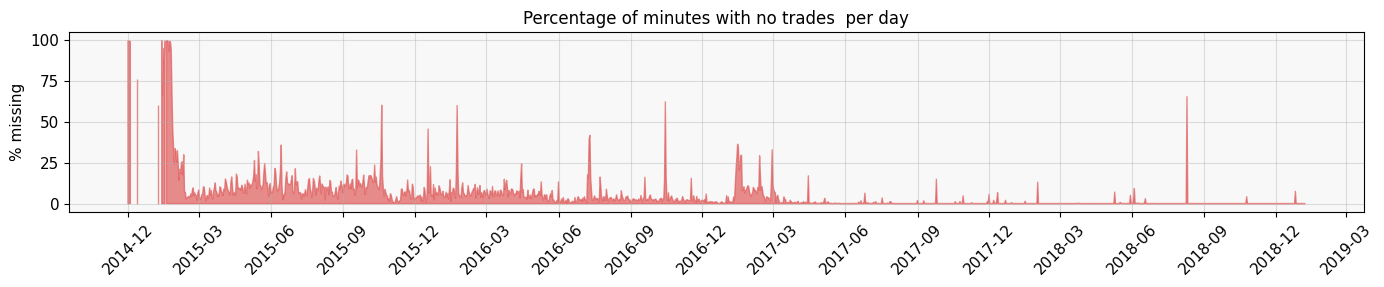

In [16]:
df_raw['datetime']   = pd.to_datetime(df_raw['Timestamp'], unit='s')
df_raw['is_missing'] = df_raw['Close'].isna().astype(int)

daily_missing = (
    df_raw.set_index('datetime')['is_missing']
    .resample('D').mean() * 100
)

fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(daily_missing.index, daily_missing.values,
                alpha=0.7, color='#e05c5c')
ax.set_title('Percentage of minutes with no trades  per day', fontsize=12)
ax.set_ylabel('% missing')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'missing_per_day.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Finding Temporal Distribution of Gaps

Missing minutes are concentrated almost entirely in the **2014–2016 period**, when
BTC trading on Coinbase was sparse and illiquid. From 2017 onward the dataset becomes
significantly denser, with very few inactive windows.

This distribution has a direct consequence for preprocessing: forward-filling across
a 38-hour gap produces 2,303 consecutive identical rows  a flat line that a neural
network would learn as a genuine price signal. Trimming the dataset to **2017-01-01**
eliminates these problematic stretches entirely.

In [17]:
is_missing  = df_raw['Close'].isna()
groups      = is_missing.ne(is_missing.shift()).cumsum()
gap_lengths = is_missing[is_missing].groupby(groups[is_missing]).count()

top_gaps = gap_lengths.sort_values(ascending=False).head(10)
print('Top 10 longest consecutive NaN gaps (minutes):')
print(top_gaps.values)
print()
print(f'Longest gap : {top_gaps.iloc[0]:,} minutes = {top_gaps.iloc[0]/60:.1f} hours')

Top 10 longest consecutive NaN gaps (minutes):
[2303 2142 1358 1326 1222 1050 1023  957  939  901]

Longest gap : 2,303 minutes = 38.4 hours


### 2.3 Finding Maximum Gap Length

The longest single uninterrupted gap spans **38.4 hours**. There are 10 gaps exceeding
15 hours in total, all located in the early sparse period. Forward-filling across a
gap of this length is not a safe strategy it would introduce an extended artificial
plateau into the training data. Trimming to 2017-01-01 resolves this entirely.

## 3. Time Series Regularity

A recurrent neural network assumes equally-spaced time steps. The NaN analysis above
counts rows that exist in the CSV with missing values. A separate question is whether
any timestamps are absent from the CSV entirely. If rows are missing rather than
simply null, they are invisible to any NaN-based check.

In [18]:
ts    = df_raw['Timestamp'].sort_values().reset_index(drop=True)
diffs = ts.diff().dropna()

print('Timestamp diff distribution (seconds):')
print(diffs.value_counts().head(10))
print()

non_60 = diffs[diffs != 60]
print(f'Rows with diff ≠ 60 seconds: {len(non_60):,}')
if len(non_60) > 0:
    print('\nLargest irregular gaps (seconds):')
    print(non_60.sort_values(ascending=False).head(8).values)

Timestamp diff distribution (seconds):
Timestamp
60.0         2099751
172380.0           1
247500.0           1
101760.0           1
175620.0           1
580200.0           1
1744080.0          1
371940.0           1
108240.0           1
Name: count, dtype: int64

Rows with diff ≠ 60 seconds: 8

Largest irregular gaps (seconds):
[1744080.  580200.  371940.  247500.  175620.  172380.  108240.  101760.]


In [19]:
ts_start      = df_raw['Timestamp'].min()
ts_end        = df_raw['Timestamp'].max()
expected_rows = (ts_end - ts_start) // 60 + 1
actual_rows   = len(df_raw)

print(f'Dataset spans : {pd.to_datetime(ts_start, unit="s")} → {pd.to_datetime(ts_end, unit="s")}')
print(f'Expected rows : {expected_rows:,}  (complete 60-second grid)')
print(f'Actual rows   : {actual_rows:,}')
print(f'Missing rows  : {expected_rows - actual_rows:,}  (timestamps absent from CSV entirely)')

Dataset spans : 2014-12-01 05:33:00 → 2019-01-07 22:06:00
Expected rows : 2,158,114  (complete 60-second grid)
Actual rows   : 2,099,760
Missing rows  : 58,354  (timestamps absent from CSV entirely)


### 3.1 Finding Two Distinct Types of Missing Data

The dataset contains two structurally different forms of missing data:

| Type | Count | Description |
|------|-------|-------------|
| NaN rows | 109,069 | Timestamp present in CSV, all values NaN |
| Missing rows | ~58,354 | Timestamp absent from the CSV entirely |

NaN rows are visible and can be detected immediately. Missing rows are invisible
until the DataFrame is reindexed against a complete 60-second DatetimeIndex,
at which point they surface as additional NaN rows.

The preprocessing pipeline must reindex first, then forward-fill  in that order.
Applying forward-fill before reindexing would leave the 58,354 hidden gaps untreated.

## 4. Feature Analysis

This section evaluates which columns carry independent predictive signal
and which are redundant or too noisy to include.

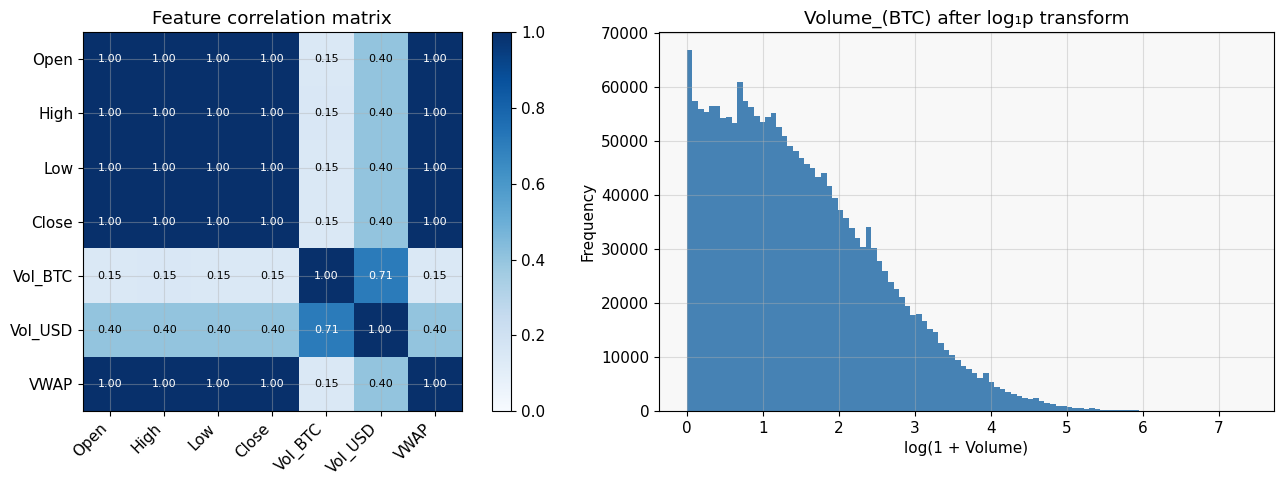

Volume_(BTC) vs Close     : 0.1479
Weighted_Price vs Close   : 1.0000
Open vs Close             : 1.0000


In [20]:
df_clean = df_raw.dropna().copy()

cols = ['Open', 'High', 'Low', 'Close', 'Volume_(BTC)', 'Volume_(Currency)', 'Weighted_Price']
corr = df_clean[cols].corr().round(4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(corr, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(len(cols)))
axes[0].set_yticks(range(len(cols)))
axes[0].set_xticklabels(['Open','High','Low','Close','Vol_BTC','Vol_USD','VWAP'],
                         rotation=45, ha='right')
axes[0].set_yticklabels(['Open','High','Low','Close','Vol_BTC','Vol_USD','VWAP'])
axes[0].set_title('Feature correlation matrix')
for i in range(len(cols)):
    for j in range(len(cols)):
        axes[0].text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                     fontsize=8, color='white' if corr.iloc[i,j] > 0.7 else 'black')
plt.colorbar(im, ax=axes[0])

log_vol = np.log1p(df_clean['Volume_(BTC)'])
axes[1].hist(log_vol, bins=100, color='steelblue', edgecolor='none')
axes[1].set_title('Volume_(BTC) after log₁p transform')
axes[1].set_xlabel('log(1 + Volume)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Volume_(BTC) vs Close     : {df_clean["Volume_(BTC)"].corr(df_clean["Close"]):.4f}')
print(f'Weighted_Price vs Close   : {df_clean["Weighted_Price"].corr(df_clean["Close"]):.4f}')
print(f'Open vs Close             : {df_clean["Open"].corr(df_clean["Close"]):.4f}')


### 4.1 Finding  Feature Decisions

| Feature | Decision | Rationale |
|---------|----------|-----------|
| Close | **Retained** | Primary prediction target |
| Open, High, Low | Dropped | Correlation with Close ≈ 1.0 across all 2M rows  no independent signal |
| Weighted_Price | Dropped | Mathematically derived from Close  pure duplicate |
| Volume_(BTC) | **Retained (log-transformed)** | Correlation of 0.15 with Close the only genuinely independent feature |
| Volume_(Currency) | Dropped | Collinear with Volume_(BTC): Volume_(Currency) = Volume_(BTC) × Price |
| Timestamp | **Encoded** | Converted to four cyclic features encoding hour-of-day and day-of-week |

**Final feature set: 6 columns**

`Close`, `volume_log`, `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`

Volume_(BTC) is right-skewed with extreme outlier spikes. The log₁p transform
compresses this distribution into an approximately normal shape before scaling.

Cyclic encoding ensures the model understands that 23:00 and 00:00 are one hour
apart not 23 hours apart as a raw integer encoding would imply.

## 5. Summary of Preprocessing Decisions

| Decision | Evidence |
|----------|----------|
| Reindex to full 60-second DatetimeIndex | 58,354 timestamps absent from CSV  must be surfaced before filling |
| Forward-fill all NaN rows | Inactive windows, not corrupted data  time structure must be preserved |
| Trim to 2017-01-01 | Gaps up to 38.4 hours in early data would introduce extended flat-line artifacts |
| Retain only Close from OHLC | All four columns have correlation ≥ 0.999 with each other |
| Retain Volume_(BTC) with log₁p | Only independent feature; log transform corrects severe right skew |
| Cyclic sin/cos encoding for time | Preserves periodicity hour 23 and hour 0 are adjacent, not opposite ends |
| Chronological split no shuffle | Shuffling leaks future price information into the training set |
| MinMaxScaler fitted on train only | Fitting on the full dataset would leak val/test price ranges into training |

All decisions above are implemented in `preprocessing.ipynb`.